# Project Delphi (Merlin)

## 03b - Model Training: Subscribers (XGBoost)

### Overview:

In this notebook, we’ll train the second of our two XGBoost models. This model predicts **total subscribers added** trained on the same feature-rich dataset we built in the `02_title_embeddings` notebook.

Because subscriber change includes **losses** as well as gains, a log transform isn’t suitable. Instead, we’ll **scale the target with `RobustScaler`** (median/IQR) to reduce the influence of spikes while preserving sign (losses vs. gains). The workflow mirrors `03a_model_training_views_xgboost`, with the only change being how we handle the target.

---

### The Plan:
1. **Load** the feature-rich dataset created in `02_title_embeddings`
2. **Inspect** the distribution of `subs_lifetime` to confirm right-skew
3. **Define** features (numeric + embeddings) and the raw target (`subs_lifetime`)
4. **Split** into training and test sets  
5. **Scale the target with `RobustScaler`**: fit on **`y_train` only**, then transform `y_train`/`y_test` (avoid leakage)
6. **Train** a baseline XGBoost regressor on the **scaled** target
7. **Fine-tune** with `RandomizedSearchCV` (5-fold CV, RMSE) to reduce error and improve generalization
8. **Evaluate** on the test set: predict in scaled space, **inverse-transform** to report RMSE/MAE/R² in **subscribers** (intuitive units)
9. **Save** artifacts for deployment in Merlin:  
   - `models/xgb_subs_model.pkl` (trained model)
   - `models/xgb_subs_target_scaler.pkl` (RobustScaler fit on the target)
   - `models/features_subs.json` (feature list & order)
   - `models/subs_model_meta.json` (optional, UI info: CV RMSE, best params, sizes)

---

### Why This Matters
- **Handles losses and gains:** Unlike a log transform, `RobustScaler` preserves negative outcomes (subscriber loss)
- **Robust to outliers:** Median/IQR scaling dampens spikes from viral or unusual episodes
- **Product-ready:** Predictions are reported in **actual subscribers**, making Merlin’s what-if engine actionable for titles that win -- or lose -- subs

## Load the feature-rich dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Start by importing pandas and then load the dataset
import pandas as pd
data_path = '/content/drive/MyDrive/Colab Notebooks/project_delphi/data/project_delphi_with_embeddings.pkl'
df = pd.read_pickle(data_path)

# Display the first few rows
df.head()

,title,duration_seconds,day_of_week,month,views_lifetime,subs_lifetime,embed_0,embed_1,embed_2,embed_3,...,embed_374,embed_375,embed_376,embed_377,embed_378,embed_379,embed_380,embed_381,embed_382,embed_383
0,Radio Layoffs Hit KNBR (Again) - Damon & Sam B...,5306.0,3,10,10666.0,45.0,-0.032426,0.004222,-0.051053,-0.048461,...,0.032988,-0.036669,-0.082085,0.019063,-0.062317,-0.000892,-0.088869,-0.032865,-0.091954,0.036114
1,Analysis: 49ers Lose To Lions In Disastrous Fa...,5234.0,1,11,5617.0,5.0,-0.046510,0.020991,-0.119065,0.021533,...,0.056652,0.021922,-0.033295,-0.063782,-0.070290,0.008837,0.021913,0.035472,0.017452,0.007911
2,"49ers Insider Matt Maiocco Talks Trades, QB Co...",4611.0,1,9,5246.0,13.0,-0.092190,-0.081139,-0.097148,0.006893,...,0.021139,0.039691,-0.008243,0.007969,-0.036037,0.009903,-0.057307,0.029755,-0.006915,0.087668
3,"49ers Analysis: Campbell Is A LOSER, Purdy TER...",5875.0,4,11,4995.0,9.0,-0.069882,-0.004827,-0.073440,-0.000911,...,0.084864,0.018908,-0.079154,-0.021822,-0.078934,0.033437,0.010721,-0.007301,0.048347,0.006759
4,49ers Analysis: Embarrassing Late-Game Loss vs...,7007.0,0,11,4814.0,37.0,-0.056615,0.003609,-0.061708,0.000720,...,0.116987,-0.016363,-0.048928,-0.050522,-0.121011,0.020156,-0.032676,0.002244,-0.048972,0.029054


## Inspect the subscribers-added distribution

In [4]:
# Check the summary stats
df.subs_lifetime.describe()

,subs_lifetime
count,298.000000
mean,3.419463
std,5.009273
min,-2.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,45.000000


As ever, plot first, model second.

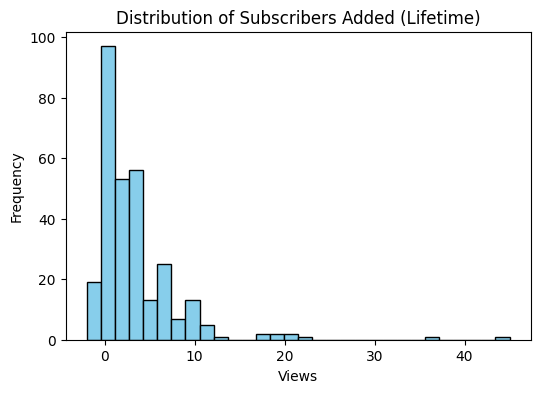

In [5]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Plot the distribution of "views_lifetime"
plt.figure(figsize=(6,4))
plt.hist(df['subs_lifetime'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Subscribers Added (Lifetime)')
plt.xlabel('Views')
plt.ylabel('Frequency')

# Display the plot
plt.show()

As expected, the subscriber-added distribution is heavily right-skewed -- most videos add only a few subs, while a small handful drive large spikes. **But there are also a few videos that *lose* subscribers**, which makes a traditional log transform unsuitable for this target. Log transforms require all values to be positive -- since the logarithm of zero or a negative number is undefined, these values break the transformation.

To keep both gains and losses while reducing the impact of extreme outliers, we’ll scale the target using `RobustScaler` instead of applying a log transform. This approach normalizes the target around its median, based on the interquartile range (IQR), making the model less sensitive to spikes from viral episodes.

## Define the target and features -- and then scale the target with `RobustScaler`

In [6]:
# Define the target and the features — numeric inputs and embeddings
# First, set y — the target as subs_lifetime
target = 'subs_lifetime'

# Important note: Need to drop the target — subs_lifetime, plus views_lifetime and title
# (which provides no predictive power, hence why we embedded it)
X = df.drop(columns=['subs_lifetime', 'views_lifetime', 'title'])
print(X.shape)

# And now set y
y = df[target]
print(y.shape)

(298, 387)
(298,)


In [7]:
# Start with the imports
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [8]:
# Split the training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
# Check the shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(238, 387)
(60, 387)
(238,)
(60,)


In [10]:
# Initialize RobustScaler -- more robust to outliers than StandardScaler
scaler=RobustScaler()

# Fit the scaler on the training target and transform both train/test
# Note: Only fit on the training set so that the model doesn't get to peek at the test set
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))


In [11]:
# Notice the new shape
y_train_scaled.shape

(238, 1)

In [12]:
# Optional check
print("Before scaling:", y_train.min(), "to", y_train.max())
print("After scaling:", y_train_scaled.min(), "to", y_train_scaled.max())

Before scaling: -2.0 to 45.0
After scaling: -1.3333333333333333 to 14.333333333333334


Here's a quick visualization:

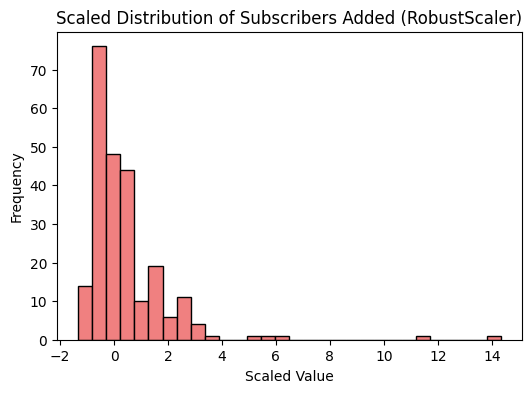

In [13]:
# Visualize the scaled distribution
plt.figure(figsize=(6,4))
plt.hist(y_train_scaled, bins=30, color='lightcoral', edgecolor='black')
plt.title("Scaled Distribution of Subscribers Added (RobustScaler)")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

The above plot proves that `RobustScaler` was the better anti-outlier tool for this situation. We'ce squashed our highly skewed data (which rnaged from -2.0 to 45.0) into a much tighter, more stable distribution centered around the median (approximately -1.3 to 14.3). The right-skew is still present, as expected, but extreme outliers are now reduced, giving the model a cleaner, more reliable target in `y_train_scaled`.

Next, we'll train a baseline XGBoost model using this scaled target to establish our baseline before fine-tuning with `RandomSearchCv`.

## Train the baseline model

In this step, we’ll train a baseline XGBoost model using the same setup from `03a_model_training_views_xgboost`. The only key differences are:
- We're now predicting `subs_lifetime` instead of `views_lifetime`
- We use `y_train_scaled`, which has been scaled with `RobustScaler`, as the target
- We add `.ravel()` to flatten the target, since XGBoost expects a 1D array

In [14]:
# Start with the imports
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize the baseline model for subscribers
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

# Run 5-fold cross-validation using the scaled target
cv_scores = cross_val_score(
    model, X_train, y_train_scaled.ravel(),
    cv=5,
    scoring="neg_root_mean_squared_error"
)

# Display results
print("Cross-val RMSE (scaled target):", -cv_scores)
print("Mean CV RMSE (scaled target):", np.mean(-cv_scores))

Cross-val RMSE (scaled target): [1.80695077 1.77604282 2.78492105 1.20902671 1.2115419 ]
Mean CV RMSE (scaled target): 1.7576966515132153


**Baseline reusults**: The baseline XGBoost model achieved a mean cross-validation RMSE of 1.758 (on the scaled target). This indicates that, on average, the model’s predictions are within about **±1.758 scaled units** of the true subscriber change.

Next, we’ll fine-tune the model using `RandomizedSearchCV` to see if we can lower this error and improve overall generalization.

## Fine-tune the baseline model with `RandomizedSearchCV`

In [15]:
# Define the base XGBoost model
base = xgb.XGBRegressor(
    random_state=42,
    tree_method="hist",
    objective="reg:squarederror"
)

# Add a few imports
from scipy.stats import randint, uniform, loguniform

# Define the hyperparameter search space
param_dist = {
    "n_estimators": randint(200, 1200),
    "learning_rate": loguniform(1e-3, 2e-1),
    "max_depth": randint(3, 10),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0.0, 2.0),
    "reg_alpha": loguniform(1e-6, 1e-1),
    "reg_lambda": loguniform(1e-2, 10.0)
}

# Import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Set up the RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=40,                            # Try 40 random combos
    scoring="neg_root_mean_squared_error",# Use RMSE
    cv=5,                                 # Run 5-fold CV
    n_jobs=-1,                            # Parallelize across CPU cores
    verbose=1,
    random_state=42,
    refit=True                            # Refit on best params
)

# Run the randomized search
# Note: This is a key difference from the block in 03a because
# we're, of course, using y_train_scaled and .ravel() to flatten the tarhet
# (make it 1D) so that XGBoost won't throw a shape error
search.fit(X_train, y_train_scaled.ravel())

# Display best results: 1) The best RMSE and 2) The corresponding set of parameters
print(f"Best CV RMSE (scaled space): {-search.best_score_:.3f}")
print("Best parameters:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV RMSE (scaled space): 1.491
Best parameters: {'colsample_bytree': np.float64(0.5687604720729966), 'gamma': np.float64(0.682132702100517), 'learning_rate': np.float64(0.0018243408217603365), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 462, 'reg_alpha': np.float64(0.0019948958651882596), 'reg_lambda': np.float64(2.8292192255361877), 'subsample': np.float64(0.7776004057997312)}


**Takeaway**: The `RandomizedSearchCV` improved upon our baseline model, dropping the scaled RMSE from 1.758 down to 1.491. The search identified a "low and slow" strategy as the winner, combining a very `low learning_rate` (0.0018) with a high number of trees, or `n_estimators`, (462). This patient approach, combined with a `max_depth` of 9 and strong regularization (`gamma`: 0.68), proved to be the most robust way to find a clear signal in our noisy subscriber data.

Now, we'll evaluate the model's performance on the test set.

## Evaluate the model on the test set

We’ll evaluate the tuned model on the unseen tes set, first reporting metrics in scaled space (what `RandomizedSearchCV` optimized), then inverse-transforming with RobustScaler to express errors in actual subscriber counts.

In [16]:
# Start with the imports -- standard regression metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Retrieve the best estimator from RandomizedSearchCV
best_model = search.best_estimator_

# Find the metrics in the scaled space -- what CV optimized
# Note: This shows how well the model performed on normalized data, before inverse-scaling
y_pred_scaled = best_model.predict(X_test)
rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled.ravel(), y_pred_scaled))
mae_scaled  = mean_absolute_error(y_test_scaled.ravel(), y_pred_scaled)
r2_scaled   = r2_score(y_test_scaled.ravel(), y_pred_scaled)
print(f"Test RMSE (scaled): {rmse_scaled:.3f} | MAE (scaled): {mae_scaled:.3f} | R² (scaled): {r2_scaled:.3f}")

# Inverse-transform the predictions back to the actual subscriber counts
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_true = scaler.inverse_transform(y_test_scaled.reshape(-1,1)).ravel()

# Compute the the metrics again in original units for intuitive interpretation
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
med_abs_err = np.median(np.abs(y_true - y_pred))

# Display the results
print(f"Test RMSE (subs): {rmse:.1f} | MAE (subs): {mae:.1f} | R²: {r2:.3f}")
print(f"Median absolute error (subs): {med_abs_err:.1f}")

Test RMSE (scaled): 1.762 | MAE (scaled): 1.142 | R² (scaled): -0.001
Test RMSE (subs): 5.3 | MAE (subs): 3.4 | R²: -0.001
Median absolute error (subs): 2.3


Let's take a look at those results:
| Metric | Result | Interpretation |
|:--|:--|:--|
| **RMSE (subs)** | 5.3 | Average prediction error ≈ ±5 subscribers per title |
| **MAE (subs)** | 3.4 | On average, predictions miss by ~3–4 subscribers |
| **Median Abs. Error (subs)** | 2.3 | Half of all predictions are within 2–3 subscribers |
| **R²** | ≈ 0 | Subscriber changes are highly volatile and difficult to predict |

**Takeaway:** Even with noise and a small sample size, the model learns subtle relationships between content features (titles + episode attibutes) and subscriber change.  

For most episodes, the model’s predictions are accurate within a few subscribers, giving a practical, real-world sense of whether an episode is likely to gain or lose subscribers -- even in a highly volatile dataset where spikes and drops are common.  

In a live **Streamlit app**, this creates an intuitive, interactive way for creators to test ideas, adjust inputs, and explore how these changes might shift subscriber outcomes.

This serves as **an early but functional prototype model** for Merlin’s interactive *what-if* engine.

## Save the artifacts for deployment in Merlin

In [17]:
# Save the trained XGBoost subscribers model and feature schema
# Start with the imports
import joblib, json
from pathlib import Path

# Define model directory
# Note: Must match the 03a path
MODELS = Path("/content/drive/MyDrive/Colab Notebooks/project_delphi/models")
MODELS.mkdir(parents=True, exist_ok=True)

# Save the tuned subscribers model (.pkl)
best_subs_model = search.best_estimator_
joblib.dump(best_subs_model, MODELS / "xgb_subs_model.pkl")
print("✔️ Saved: xgb_subs_model.pkl")

# Save the booster (.json)
subs_booster = best_subs_model.get_booster()
subs_booster.save_model(MODELS / "xgb_subs_booster.json")
print("✔️ Saved: xgb_subs_booster.json")

# Save the target scaler (RobustScaler)
joblib.dump(scaler, MODELS / "xgb_subs_target_scaler.pkl")
print("✔️ Saved: xgb_subs_target_scaler.pkl")

# Save feature column order as JSON
subs_feature_cols = list(X_train.columns)
with open(MODELS / "features_subs.json", "w") as f:
    json.dump({"feature_cols": subs_feature_cols}, f)
print("✔️ Saved: features_subs.json")

print("All subscriber artifacts saved successfully in:", MODELS)

✔️ Saved: xgb_subs_model.pkl
✔️ Saved: xgb_subs_booster.json
✔️ Saved: xgb_subs_target_scaler.pkl
✔️ Saved: features_subs.json
All subscriber artifacts saved successfully in: /content/drive/MyDrive/Colab Notebooks/project_delphi/models
